<a href="https://colab.research.google.com/github/MR-Xcloud/Exploratory-Data-analysis--Retail/blob/main/facial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 20.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.15.0 requires protobuf<4.21,>=3.20.3; python_version < "3.11", but you have protobuf 4.25.4 which is incompatible.


In [ ]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh

# For static images:
IMAGE_FILES = ['human-face-women-portrait-260nw-296481974.jpg']
drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5) as face_mesh:
  for idx, file in enumerate(IMAGE_FILES):
    image = cv2.imread(file)
    # Convert the BGR image to RGB before processing.
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    # Print and draw face mesh landmarks on the image.
    if not results.multi_face_landmarks:
      continue
    annotated_image = image.copy()
    for face_landmarks in results.multi_face_landmarks:
      print('face_landmarks:', face_landmarks)
      mp_drawing.draw_landmarks(
          image=annotated_image,
          landmark_list=face_landmarks,
          connections=mp_face_mesh.FACEMESH_TESSELATION,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp_drawing_styles
          .get_default_face_mesh_tesselation_style())
      mp_drawing.draw_landmarks(
          image=annotated_image,
          landmark_list=face_landmarks,
          connections=mp_face_mesh.FACEMESH_CONTOURS,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp_drawing_styles
          .get_default_face_mesh_contours_style())
      mp_drawing.draw_landmarks(
          image=annotated_image,
          landmark_list=face_landmarks,
          connections=mp_face_mesh.FACEMESH_IRISES,
          landmark_drawing_spec=None,
          connection_drawing_spec=mp_drawing_styles
          .get_default_face_mesh_iris_connections_style())
    cv2.imwrite('/tmp/annotated_image' + str(idx) + '.png', annotated_image)

    drawing_spec = mp_drawing.DrawingSpec(thickness=1, circle_radius=1)
cap = cv2.VideoCapture(0)
with mp_face_mesh.FaceMesh(
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5) as face_mesh:
  while cap.isOpened():
    success, image = cap.read()
    if not success:
      print("Ignoring empty camera frame.")
      # If loading a video, use 'break' instead of 'continue'.
      continue


    # To improve performance, optionally mark the image as not writeable to
    # pass by reference.
    image.flags.writeable = False
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(image)

    # Draw the face mesh annotations on the image.
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    if results.multi_face_landmarks:
      for face_landmarks in results.multi_face_landmarks:
        mp_drawing.draw_landmarks(
            image=image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles
            .get_default_face_mesh_tesselation_style())
        mp_drawing.draw_landmarks(
            image=image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles
            .get_default_face_mesh_contours_style())
        mp_drawing.draw_landmarks(
            image=image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles
            .get_default_face_mesh_iris_connections_style())
    # Flip the image horizontally for a selfie-view display.
    cv2_imshow(cv2.flip(image, 1))
    if cv2.waitKey(5) & 0xFF == 27:
      break
cap.release()

face_landmarks: landmark {
  x: 0.473580182
  y: 0.529815376
  z: -0.0366712399
}
landmark {
  x: 0.472493917
  y: 0.48502636
  z: -0.0840689316
}
landmark {
  x: 0.472387493
  y: 0.499123871
  z: -0.044398848
}
landmark {
  x: 0.459306836
  y: 0.41808182
  z: -0.0665866658
}
landmark {
  x: 0.472268909
  y: 0.464402765
  z: -0.0899728462
}
landmark {
  x: 0.471814483
  y: 0.437416285
  z: -0.0850498602
}
landmark {
  x: 0.471087724
  y: 0.372451603
  z: -0.0472640805
}
landmark {
  x: 0.358777314
  y: 0.361310333
  z: 0.0131545803
}
landmark {
  x: 0.470922291
  y: 0.321914643
  z: -0.0377063416
}
landmark {
  x: 0.47106424
  y: 0.295367956
  z: -0.0417204238
}
landmark {
  x: 0.472159624
  y: 0.195138901
  z: -0.0331149511
}
landmark {
  x: 0.473849177
  y: 0.537111282
  z: -0.0344293602
}
landmark {
  x: 0.474288315
  y: 0.544528663
  z: -0.0303923376
}
landmark {
  x: 0.474710286
  y: 0.549030721
  z: -0.0253069773
}
landmark {
  x: 0.474889249
  y: 0.58044517
  z: -0.0148676615
}


In [ ]:
for landmark in face_landmarks.landmark:  # Iterate over the landmarks within face_landmarks
  x = landmark.x
  y = landmark.y
  z = landmark.z
  print((x, y, z), sep=',', end=',\n')

(0.47358018159866333, 0.5298153758049011, -0.036671239882707596),
(0.4724939167499542, 0.48502635955810547, -0.08406893163919449),
(0.47238749265670776, 0.49912387132644653, -0.044398847967386246),
(0.45930683612823486, 0.4180818200111389, -0.06658666580915451),
(0.4722689092159271, 0.4644027650356293, -0.0899728462100029),
(0.47181448340415955, 0.43741628527641296, -0.08504986017942429),
(0.4710877239704132, 0.3724516034126282, -0.04726408049464226),
(0.35877731442451477, 0.36131033301353455, 0.013154580257833004),
(0.4709222912788391, 0.3219146430492401, -0.037706341594457626),
(0.4710642397403717, 0.295367956161499, -0.041720423847436905),
(0.47215962409973145, 0.19513890147209167, -0.033114951103925705),
(0.47384917736053467, 0.5371112823486328, -0.034429360181093216),
(0.47428831458091736, 0.5445286631584167, -0.03039233759045601),
(0.47471028566360474, 0.5490307211875916, -0.025306977331638336),
(0.47488924860954285, 0.5804451704025269, -0.014867661520838737),
(0.4753467142581939

In [ ]:
import plotly.graph_objects as go
landmarks = [(landmark.x, landmark.y, landmark.z)
             for landmark in face_landmarks.landmark]
x, y, z = zip(*landmarks)

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(x=x, y=y, z=z, mode='markers')])

# Customize layout
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
                  title="3D Facial Landmarks")
fig.show()


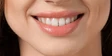

In [ ]:
import cv2
import mediapipe as mp
from google.colab.patches import cv2_imshow

# Initialize MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

# Load the image
image = cv2.imread('human-face-women-portrait-260nw-296481974.jpg')
height, width, _ = image.shape

# Convert the BGR image to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Perform facial landmark detection
results = face_mesh.process(rgb_image)

# Extract landmarks if faces are detected
if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        # Select landmarks below the nose
        # Landmark 1: nose tip
        # Landmark 152: chin
        # Landmarks 234 and 454: left and right sides of the jaw

        nose_tip = face_landmarks.landmark[1]
        chin = face_landmarks.landmark[152]
        left_jaw = face_landmarks.landmark[234]
        right_jaw = face_landmarks.landmark[454]

        # Calculate the bounding box
        x_min = int(min(nose_tip.x, chin.x, left_jaw.x, right_jaw.x) * width)
        x_max = int(max(nose_tip.x, chin.x, left_jaw.x, right_jaw.x) * width)
        y_min = int(nose_tip.y * height)
        y_max = int(chin.y * height)

        # Crop the region below the nose
        cropped_image = image[y_min:y_max, x_min:x_max]

        # Visualize the cropped image
        cv2_imshow(cropped_image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

# Clean up
face_mesh.close()


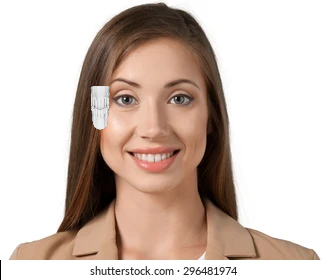

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the background image and 2D model (with alpha channel)
background = cv2.imread('human-face-women-portrait-260nw-296481974.jpg')
if background is None:  # Check if image loading was successful
    print("Error: Could not load background image. Check the file path.")
    exit()  # Exit the script if the image is not found

model = cv2.imread('teethmodel-removebg-preview.png', cv2.IMREAD_UNCHANGED)  # Load with alpha channel

# Resize the model if necessary (optional)
model = cv2.resize(model, (100, 100))  # Resize to desired dimensions

# Separate the alpha channel from the model
if model.shape[2] == 4:  # Check if alpha channel exists
    bgr_model = model[:, :, :3]
    alpha_model = model[:, :, 3] / 255.0
else:
    bgr_model = model
    alpha_model = np.ones((model.shape[0], model.shape[1]))

# Define the position where the model will be placed
x, y = 50, 50  # Top-left corner of the placement

# Create a mask for blending
alpha_mask = alpha_model[:, :, np.newaxis]  # Add channel dimension
alpha_inv = 1.0 - alpha_mask

# Calculate the region of interest (ROI) on the background image
roi = background[y:y + model.shape[0], x:x + model.shape[1]]

# Blend the model with the ROI
blended_roi = (alpha_mask * bgr_model + alpha_inv * roi).astype(np.uint8)

# Place the blended ROI back on the background image
background[y:y + model.shape[0], x:x + model.shape[1]] = blended_roi

# Save or display the final image
cv2.imwrite('placed_model.jpg', background)
cv2_imshow(background)
cv2.waitKey(0)
cv2.destroyAllWindows()


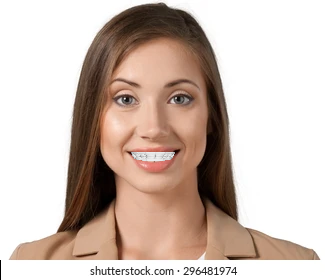

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load the background image and 2D model
background = cv2.imread('human-face-women-portrait-260nw-296481974.jpg')
model = cv2.imread('teethmodel-removebg-preview.png', cv2.IMREAD_UNCHANGED)  # Load with alpha channel

# Define the desired size for the model
desired_width = 230  # Example width in pixels
desired_height = 20  # Example height in pixels

# Resize the model to the desired size
model_resized = cv2.resize(model, (desired_width, desired_height))

# Separate the alpha channel from the resized model
if model_resized.shape[2] == 4:  # Check if alpha channel exists
    bgr_model = model_resized[:, :, :3]
    alpha_model = model_resized[:, :, 3] / 255.0
else:
    bgr_model = model_resized
    alpha_model = np.ones((model_resized.shape[0], model_resized.shape[1]))

# Create an alpha mask for blending
alpha_mask = alpha_model[:, :, np.newaxis]  # Add channel dimension
alpha_inv = 1.0 - alpha_mask

# Define the position where you want to place the model on the background
x_offset = 38  # X-coordinate of the top-left corner where the model will be placed
y_offset = 145  # Y-coordinate of the top-left corner where the model will be placed

# Make sure the model fits within the background dimensions
if (x_offset + model_resized.shape[1] > background.shape[1]) or (y_offset + model_resized.shape[0] > background.shape[0]):
    raise ValueError("Model size or position is out of bounds of the background image.")

# Create a region of interest (ROI) in the background
roi = background[y_offset:y_offset + model_resized.shape[0], x_offset:x_offset + model_resized.shape[1]]

# Blend the model with the ROI
blended_roi = (alpha_mask * bgr_model + alpha_inv * roi).astype(np.uint8)

# Place the blended ROI back onto the background
background[y_offset:y_offset + model_resized.shape[0], x_offset:x_offset + model_resized.shape[1]] = blended_roi

# Save or display the blended image
cv2.imwrite('blended_image.jpg', background)
cv2_imshow(background)
cv2.waitKey(0)
cv2.destroyAllWindows()
